# Detecting AI-Generated vs Human-Written Text
**Chandana Mahesh | Individual Project**



## How to Run

1. Open this notebook in Google Colab.
2. Upload `AI_Human.csv.zip` to the Colab environment.
3. Run all cells from top to bottom.
4. The notebook will:
   - Load the dataset
   - Train baseline models
   - Train machine learning/deep learning models
   - Evaluate models on validation and test sets
   - Run external validation
   - Save final results to CSV

## Dataset

The main dataset file required is:

`AI_Human.csv.zip`

Link: https://www.kaggle.com/datasets/shanegerami/ai-vs-human-text

Expected columns:
- `text`
- `generated`

Label meaning:
- `0 = Human-written`
- `1 = AI-generated`

In [ ]:
# Install required packages
!pip install transformers datasets accelerate sentencepiece -q
!pip install wordcloud -q

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
print("Libraries installed")

Libraries installed


In [ ]:
# Import all libraries
# ── Standard ──────────────────────────────────────────────
import re, random, warnings, zipfile
import numpy as np
import pandas as pd

# ── Visualization ─────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ── Scikit-learn ──────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ── TensorFlow / Keras (LSTM trained from scratch) ────────
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Dense, Dropout,
    Conv1D, GlobalMaxPooling1D, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping

# ── PyTorch + HuggingFace Transformers ────────────────────
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    AutoModel, get_linear_schedule_with_warmup
)
from torch.optim import AdamW

warnings.filterwarnings("ignore")

# ── GPU Check ─────────────────────────────────────────────
print("TensorFlow GPU:", tf.config.list_physical_devices("GPU"))
print("PyTorch CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

TensorFlow GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch CUDA: True
GPU: Tesla T4
Using device: cuda


## Set Random Seeds

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Seeds set to", SEED)

Seeds set to 42


## Load Dataset

In [ ]:
# ── Load from uploaded ZIP ──────────────────────
#zip_path    = "/content/AI_Human.csv"
#extract_dir = "/content/dataset"
#os.makedirs(extract_dir, exist_ok=True)

#with zipfile.ZipFile(zip_path, 'r') as z:
    #z.extractall(extract_dir)

#csv_path = os.path.join(extract_dir, "AI_Human.csv")
csv_path = "/content/AI_Human.csv"
df = pd.read_csv(csv_path)

# ── Sanity check ──────────────────────────────────────────
TEXT_COL  = "text"
LABEL_COL = "generated"

df[LABEL_COL] = df[LABEL_COL].astype(int)
df = df.drop_duplicates(subset=[TEXT_COL]).reset_index(drop=True)

print("Shape:", df.shape)
print(df[LABEL_COL].value_counts())
display(df.head(3))

Shape: (487235, 2)
generated
0    305797
1    181438
Name: count, dtype: int64


,text,generated
0,Cars. Cars have been around since they became ...,0
1,Transportation is a large necessity in most co...,0
2,"""America's love affair with it's vehicles seem...",0


## Exploratory Data Analysis (EDA)

       word_count  char_count  sent_count  avg_word_len
count   487235.00   487235.00   487235.00     487235.00
mean       393.10     2269.59       20.66          4.76
std        168.59      988.81        9.20          0.52
min          0.00        1.00        0.00          0.00
25%        278.00     1583.00       14.00          4.42
50%        363.00     2102.00       20.00          4.69
75%        471.00     2724.00       26.00          5.02
max       1668.00    18322.00      155.00        126.00


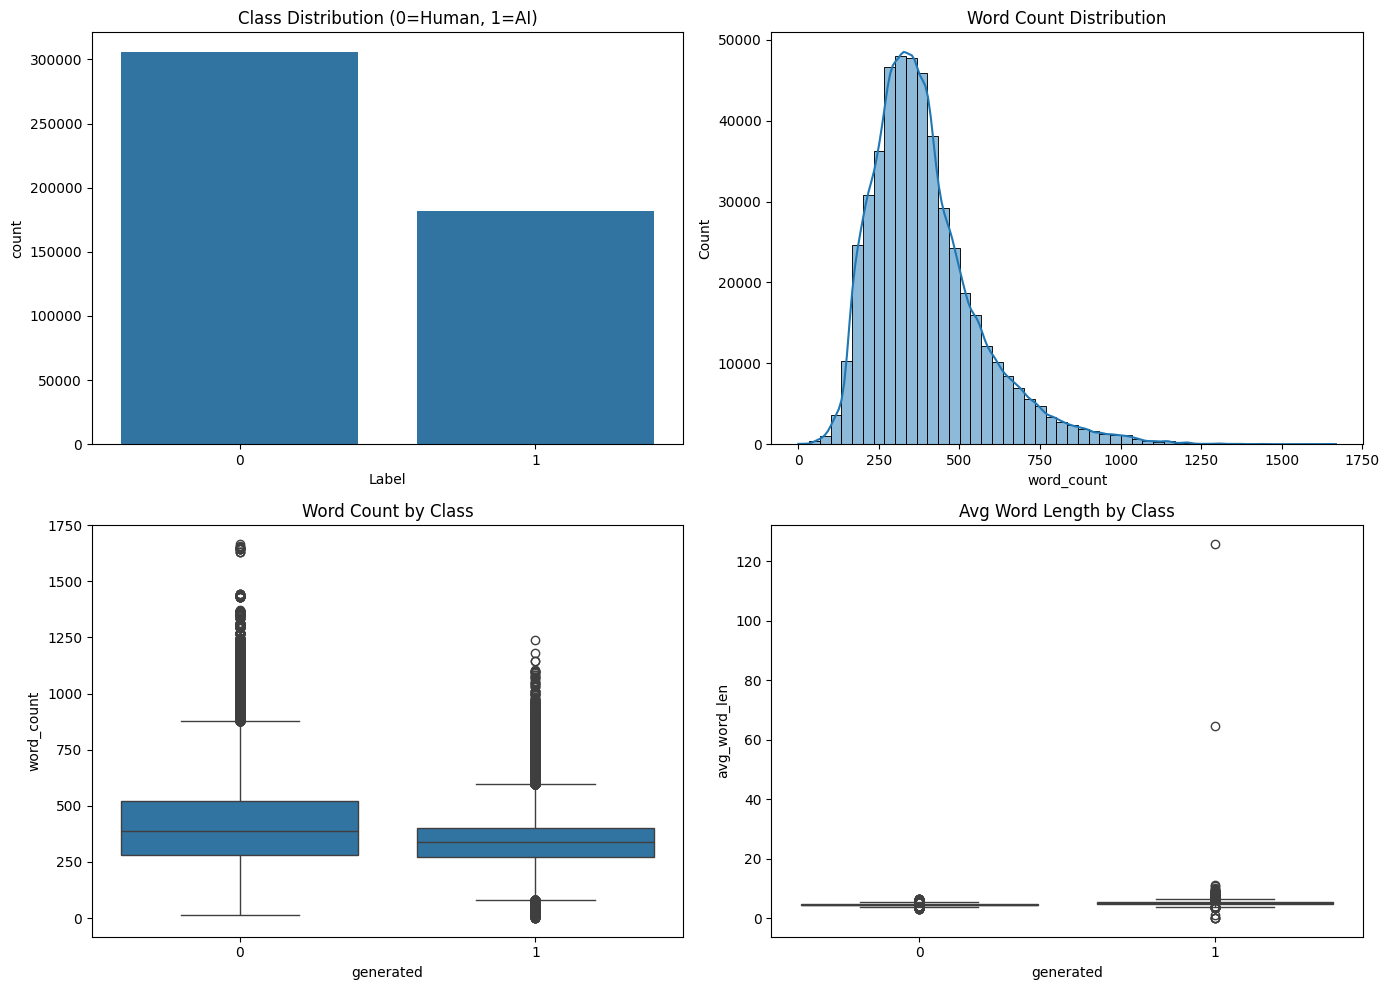

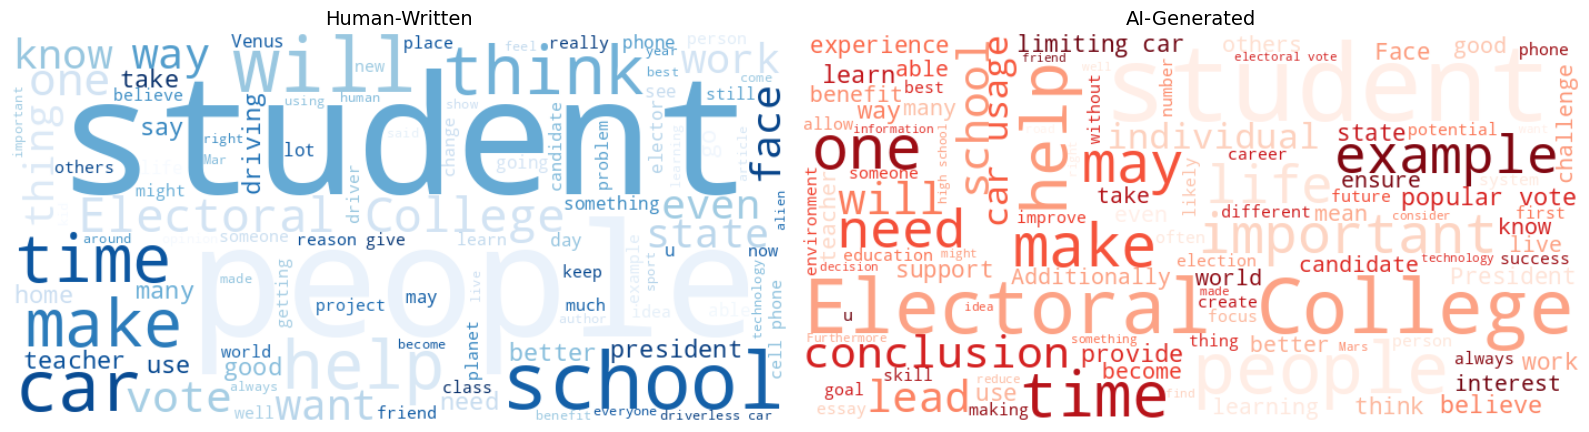

In [ ]:
# ── Text length features ───────────────────────────────────
df["word_count"]     = df[TEXT_COL].apply(lambda x: len(x.split()))
df["char_count"]     = df[TEXT_COL].apply(len)
df["sent_count"]     = df[TEXT_COL].apply(
    lambda x: len([s for s in re.split(r"[.!?]+", x) if s.strip()])
)
df["avg_word_len"]   = df[TEXT_COL].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)
df["punct_count"]    = df[TEXT_COL].apply(
    lambda x: len(re.findall(r"[.,!?;:]", x))
)

stop_words = set(ENGLISH_STOP_WORDS)
df["stopword_ratio"] = df[TEXT_COL].apply(
    lambda x: sum(1 for w in x.lower().split() if w in stop_words) / max(len(x.split()), 1)
)

print(df[["word_count","char_count","sent_count","avg_word_len"]].describe().round(2))

# ── Plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Class distribution
sns.countplot(x=LABEL_COL, data=df, ax=axes[0,0])
axes[0,0].set_title("Class Distribution (0=Human, 1=AI)")
axes[0,0].set_xlabel("Label")

# Word count distribution
sns.histplot(df["word_count"], bins=50, kde=True, ax=axes[0,1])
axes[0,1].set_title("Word Count Distribution")

# Word count by class
sns.boxplot(x=LABEL_COL, y="word_count", data=df, ax=axes[1,0])
axes[1,0].set_title("Word Count by Class")

# Avg word length by class
sns.boxplot(x=LABEL_COL, y="avg_word_len", data=df, ax=axes[1,1])
axes[1,1].set_title("Avg Word Length by Class")

plt.tight_layout()
plt.show()

# ── Word clouds ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for label, title, ax in zip([0, 1], ["Human-Written", "AI-Generated"], axes):
    text = " ".join(df[df[LABEL_COL]==label][TEXT_COL].sample(500, random_state=SEED))
    wc   = WordCloud(width=700, height=350, background_color="white",
                     max_words=100, colormap="Blues" if label==0 else "Reds").generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title, fontsize=14)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Text Cleaning

In [ ]:
def clean_text(text: str) -> str:
    """
    Lightweight cleaning used for classical ML + LSTM.
    NOTE: BERT/Qwen use RAW text — transformers handle their own tokenization.
    """
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)   # remove URLs
    text = re.sub(r"<.*?>", "", text)              # remove HTML
    text = re.sub(r"[^a-zA-Z\s]", " ", text)       # keep letters only
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df[TEXT_COL].apply(clean_text)
display(df[[TEXT_COL, "clean_text"]].head(3))
print("Text cleaning complete")

,text,clean_text
0,Cars. Cars have been around since they became ...,cars cars have been around since they became f...
1,Transportation is a large necessity in most co...,transportation is a large necessity in most co...
2,"""America's love affair with it's vehicles seem...",america s love affair with it s vehicles seems...


Text cleaning complete


## Block 7: Train / Validation / Test Split (70 / 15 / 15)

In [ ]:
X_clean = df["clean_text"]
X_raw   = df[TEXT_COL]          # raw text — used by BERT / Qwen
y       = df[LABEL_COL]

# First split: 70% train, 30% temp
Xc_tr, Xc_tmp, Xr_tr, Xr_tmp, y_tr, y_tmp = train_test_split(
    X_clean, X_raw, y, test_size=0.30, random_state=SEED, stratify=y
)

# Second split: 15% val, 15% test (from 30% temp)
Xc_val, Xc_test, Xr_val, Xr_test, y_val, y_test = train_test_split(
    Xc_tmp, Xr_tmp, y_tmp, test_size=0.50, random_state=SEED, stratify=y_tmp
)

print(f"Train : {len(Xc_tr):>7,}")
print(f"Val   : {len(Xc_val):>7,}")
print(f"Test  : {len(Xc_test):>7,}")

Train : 341,064
Val   :  73,085
Test  :  73,086


## Block 8: Evaluation Helper

In [ ]:
results = []   # stores all model results for final comparison

def evaluate_model(y_true, y_pred, model_name: str, split="Validation") -> dict:
    """Compute metrics, print report, draw confusion matrix."""
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n{'='*50}")
    print(f" {model_name} [{split}]")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Human","AI"]))

    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Human","AI"])
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.show()

    return {"Model": model_name, "Split": split,
            "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

print("Evaluate_model() ready")

Evaluate_model() ready


---
## Baseline Models
*(Majority class & Stratified — reference points only)*


 Majority Class Baseline [Validation]
  Accuracy : 0.6276
  Precision: 0.0000
  Recall   : 0.0000
  F1-score : 0.0000

              precision    recall  f1-score   support

       Human       0.63      1.00      0.77     45869
          AI       0.00      0.00      0.00     27216

    accuracy                           0.63     73085
   macro avg       0.31      0.50      0.39     73085
weighted avg       0.39      0.63      0.48     73085



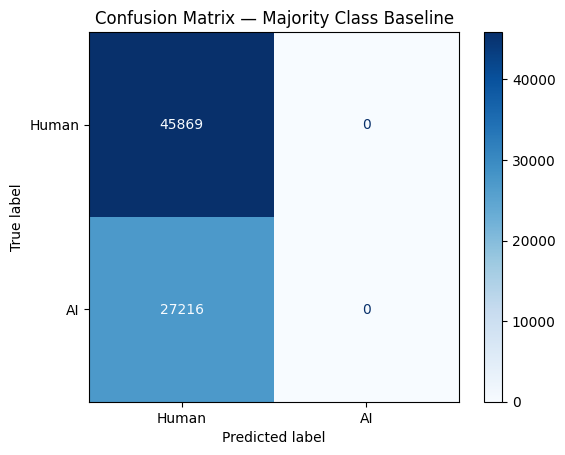


 Stratified Baseline [Validation]
  Accuracy : 0.5347
  Precision: 0.3751
  Recall   : 0.3747
  F1-score : 0.3749

              precision    recall  f1-score   support

       Human       0.63      0.63      0.63     45869
          AI       0.38      0.37      0.37     27216

    accuracy                           0.53     73085
   macro avg       0.50      0.50      0.50     73085
weighted avg       0.53      0.53      0.53     73085



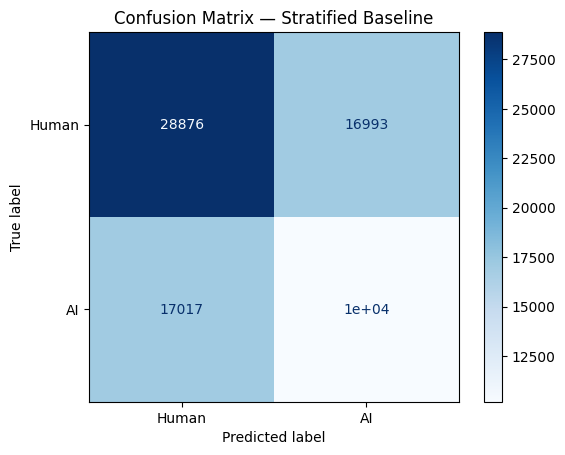

In [ ]:
for strategy, name in [("most_frequent", "Majority Class Baseline"),
                        ("stratified",    "Stratified Baseline")]:
    clf = DummyClassifier(strategy=strategy, random_state=SEED)
    clf.fit(Xc_tr.to_frame(), y_tr)
    y_pred = clf.predict(Xc_val.to_frame())
    results.append(evaluate_model(y_val, y_pred, name))

---
## TF-IDF + Logistic Regression
*(Sparse bag-of-words — no embedding)*


 TF-IDF + LogReg [Validation]
  Accuracy : 0.9957
  Precision: 0.9970
  Recall   : 0.9915
  F1-score : 0.9942

              precision    recall  f1-score   support

       Human       0.99      1.00      1.00     45869
          AI       1.00      0.99      0.99     27216

    accuracy                           1.00     73085
   macro avg       1.00      0.99      1.00     73085
weighted avg       1.00      1.00      1.00     73085



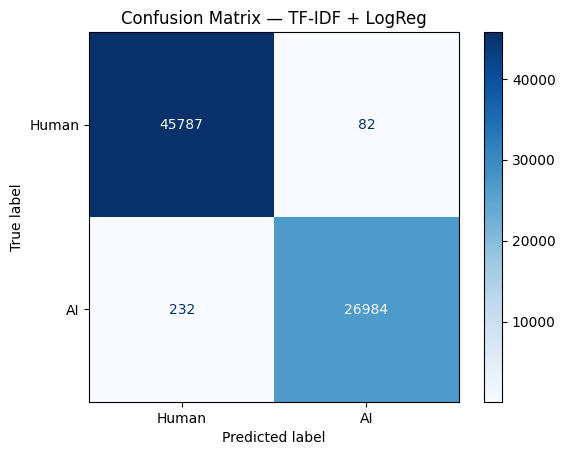


 TF-IDF + LogReg [Test]
  Accuracy : 0.9959
  Precision: 0.9976
  Recall   : 0.9914
  F1-score : 0.9945

              precision    recall  f1-score   support

       Human       0.99      1.00      1.00     45870
          AI       1.00      0.99      0.99     27216

    accuracy                           1.00     73086
   macro avg       1.00      1.00      1.00     73086
weighted avg       1.00      1.00      1.00     73086



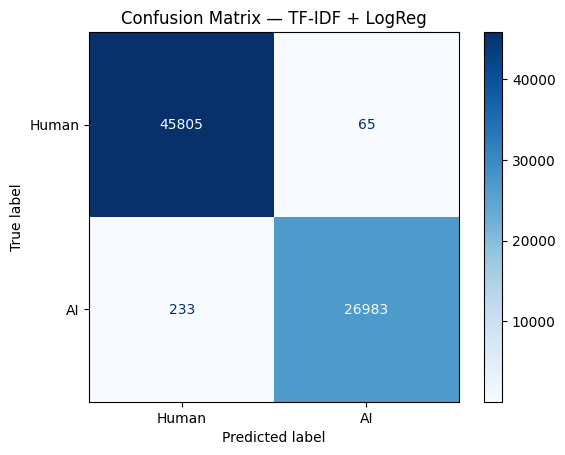

In [ ]:
# ── Vectorise ──────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1,2), min_df=2)
X_tr_tfidf  = tfidf.fit_transform(Xc_tr)
X_val_tfidf = tfidf.transform(Xc_val)
X_te_tfidf  = tfidf.transform(Xc_test)

# ── Train ──────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
lr.fit(X_tr_tfidf, y_tr)

# ── Val + Test ─────────────────────────────────────────────
results.append(evaluate_model(y_val,  lr.predict(X_val_tfidf), "TF-IDF + LogReg", "Validation"))
results.append(evaluate_model(y_test, lr.predict(X_te_tfidf),  "TF-IDF + LogReg", "Test"))

---
## LSTM with Embeddings Trained FROM SCRATCH


In [ ]:
MAX_VOCAB = 20_000
MAX_LEN   = 256    # increased from 200 for better context capture
EMBED_DIM = 128    # embedding dimension trained from scratch

# ── Tokenize ──────────────────────────────────────────────
tok = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tok.fit_on_texts(Xc_tr)                               # fit ONLY on train

def to_padded(texts):
    seqs = tok.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding="post", truncating="post")

X_tr_pad  = to_padded(Xc_tr)
X_val_pad = to_padded(Xc_val)
X_te_pad  = to_padded(Xc_test)

print(f"Train padded: {X_tr_pad.shape}")

Train padded: (341064, 256)


In [ ]:
# ── Architecture ───────────────────────────────────────────
# Embedding layer is randomly initialised and TRAINED FROM SCRATCH
lstm_model = Sequential([
    Embedding(input_dim=MAX_VOCAB,     # vocabulary size
              output_dim=EMBED_DIM,    # 128-dim dense vectors (learned)
              input_length=MAX_LEN,
              name="scratch_embedding"),   # <-- trained from scratch
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),
    Bidirectional(LSTM(32)),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
], name="BiLSTM_scratch_embedding")

lstm_model.compile(optimizer="adam",
                   loss="binary_crossentropy",
                   metrics=["accuracy"])
lstm_model.summary()

print("\n Embedding layer is randomly initialised and trained from scratch")

Model: "BiLSTM_scratch_embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ scratch_embedding (Embedding)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


 Embedding layer is randomly initialised and trained from scratch


Epoch 1/5
5330/5330 ━━━━━━━━━━━━━━━━━━━━ 263s 47ms/step - accuracy: 0.9797 - loss: 0.0633 - val_accuracy: 0.9943 - val_loss: 0.0219
Epoch 2/5
5330/5330 ━━━━━━━━━━━━━━━━━━━━ 251s 47ms/step - accuracy: 0.9948 - loss: 0.0177 - val_accuracy: 0.9965 - val_loss: 0.0139
Epoch 3/5
5330/5330 ━━━━━━━━━━━━━━━━━━━━ 252s 47ms/step - accuracy: 0.9976 - loss: 0.0080 - val_accuracy: 0.9978 - val_loss: 0.0078
Epoch 4/5
5330/5330 ━━━━━━━━━━━━━━━━━━━━ 250s 47ms/step - accuracy: 0.9986 - loss: 0.0046 - val_accuracy: 0.9983 - val_loss: 0.0059
Epoch 5/5
5330/5330 ━━━━━━━━━━━━━━━━━━━━ 254s 48ms/step - accuracy: 0.9990 - loss: 0.0031 - val_accuracy: 0.9987 - val_loss: 0.0058


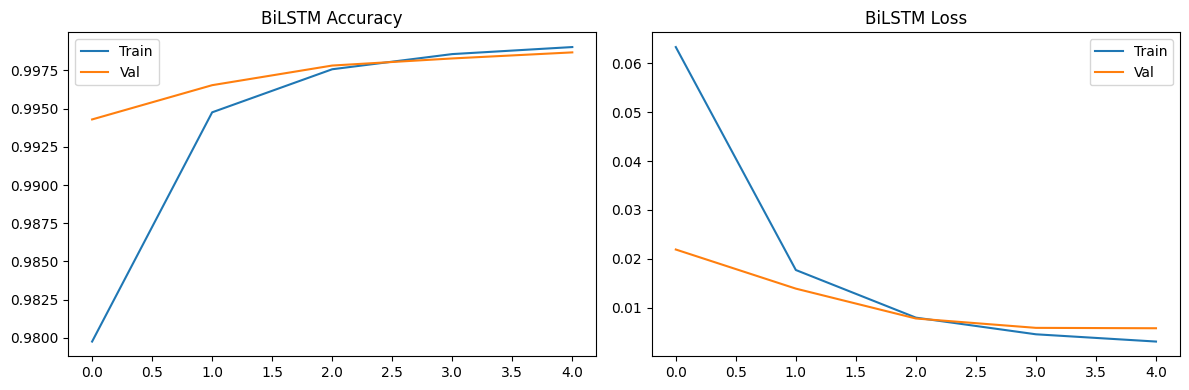

2284/2284 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step
2284/2284 ━━━━━━━━━━━━━━━━━━━━ 40s 18ms/step

 BiLSTM (scratch embed) [Validation]
  Accuracy : 0.9987
  Precision: 0.9989
  Recall   : 0.9976
  F1-score : 0.9982

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00     45869
          AI       1.00      1.00      1.00     27216

    accuracy                           1.00     73085
   macro avg       1.00      1.00      1.00     73085
weighted avg       1.00      1.00      1.00     73085



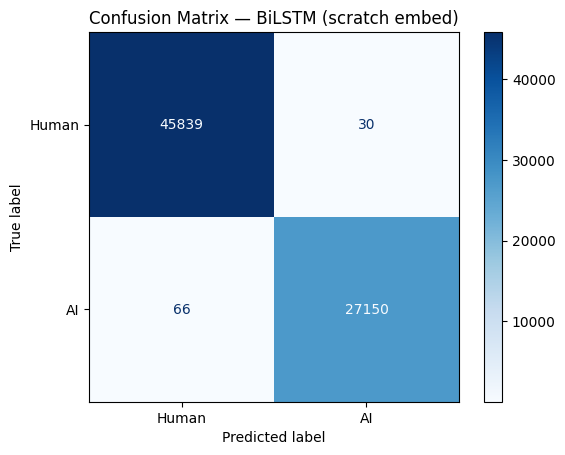


 BiLSTM (scratch embed) [Test]
  Accuracy : 0.9988
  Precision: 0.9989
  Recall   : 0.9978
  F1-score : 0.9984

              precision    recall  f1-score   support

       Human       1.00      1.00      1.00     45870
          AI       1.00      1.00      1.00     27216

    accuracy                           1.00     73086
   macro avg       1.00      1.00      1.00     73086
weighted avg       1.00      1.00      1.00     73086



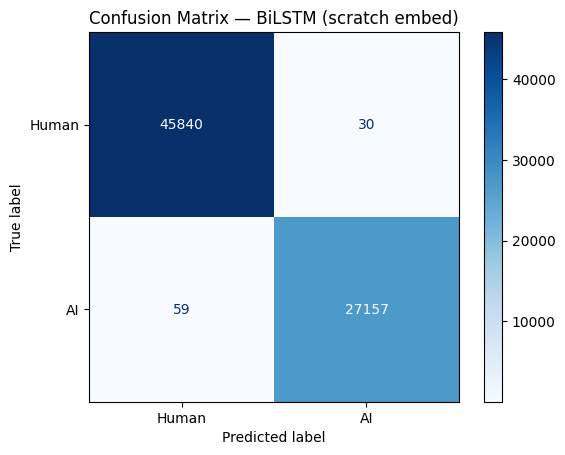

In [ ]:
# ── Train ──────────────────────────────────────────────────
early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_tr_pad, y_tr,
    validation_data=(X_val_pad, y_val),
    epochs=5,
    batch_size=64,
    callbacks=[early_stop]
)

# ── Learning curves ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(axes, ["accuracy","loss"], ["Accuracy","Loss"]):
    ax.plot(history_lstm.history[metric],     label="Train")
    ax.plot(history_lstm.history[f"val_{metric}"], label="Val")
    ax.set_title(f"BiLSTM {title}")
    ax.legend()
plt.tight_layout(); plt.show()

# ── Evaluate ───────────────────────────────────────────────
y_pred_lstm_val  = (lstm_model.predict(X_val_pad)  > 0.5).astype(int).flatten()
y_pred_lstm_test = (lstm_model.predict(X_te_pad)   > 0.5).astype(int).flatten()
results.append(evaluate_model(y_val,  y_pred_lstm_val,  "BiLSTM (scratch embed)", "Validation"))
results.append(evaluate_model(y_test, y_pred_lstm_test, "BiLSTM (scratch embed)", "Test"))

---
## BERT Fine-Tuning
*(Pretrained contextual embeddings — fine-tuned on task)*

In [ ]:
# ── PyTorch Dataset wrapper ────────────────────────────────
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(self.labels[idx], dtype=torch.long)
        }


def train_transformer(model_name: str,
                      X_tr, X_val, X_te,
                      y_tr, y_val, y_te,
                      max_len=128, batch_size=16,
                      epochs=2, lr=2e-5):
    """
    Fine-tune any HuggingFace classification model.
    Returns val predictions, test predictions.
    """
    print(f"\n🔄 Loading {model_name} ...")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model     = AutoModelForSequenceClassification.from_pretrained(
                    model_name, num_labels=2).to(DEVICE)

    # Datasets + loaders
    train_ds = TextDataset(X_tr,  y_tr,  tokenizer, max_len)
    val_ds   = TextDataset(X_val, y_val, tokenizer, max_len)
    test_ds  = TextDataset(X_te,  y_te,  tokenizer, max_len)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size*2)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size*2)

    # Optimiser + scheduler
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
                    optimizer,
                    num_warmup_steps=total_steps // 10,
                    num_training_steps=total_steps)

    train_accs, val_accs = [], []

    for epoch in range(1, epochs+1):
        # ── Train ──────────────────────────────────────────
        model.train()
        total_loss, correct, total = 0, 0, 0
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            lbls = batch["label"].to(DEVICE)

            optimizer.zero_grad()
            out  = model(input_ids=ids, attention_mask=mask, labels=lbls)
            loss = out.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            preds = out.logits.argmax(-1)
            correct += (preds == lbls).sum().item()
            total   += len(lbls)

        tr_acc = correct / total
        train_accs.append(tr_acc)

        # ── Validate ───────────────────────────────────────
        model.eval()
        v_preds, v_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE)
                mask = batch["attention_mask"].to(DEVICE)
                out  = model(input_ids=ids, attention_mask=mask)
                v_preds.extend(out.logits.argmax(-1).cpu().numpy())
                v_labels.extend(batch["label"].numpy())

        val_acc = accuracy_score(v_labels, v_preds)
        val_accs.append(val_acc)
        print(f"  Epoch {epoch}/{epochs} | Train Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f} | Loss: {total_loss/len(train_loader):.4f}")

    # ── Learning curves ────────────────────────────────────
    plt.figure(figsize=(7,4))
    plt.plot(train_accs, label="Train", marker="o")
    plt.plot(val_accs,   label="Val",   marker="o")
    plt.title(f"{model_name} — Accuracy per Epoch")
    plt.legend(); plt.show()

    # ── Test predictions ───────────────────────────────────
    model.eval()
    t_preds = []
    with torch.no_grad():
        for batch in test_loader:
            ids  = batch["input_ids"].to(DEVICE)
            mask = batch["attention_mask"].to(DEVICE)
            out  = model(input_ids=ids, attention_mask=mask)
            t_preds.extend(out.logits.argmax(-1).cpu().numpy())

    return np.array(v_preds), np.array(t_preds), model, tokenizer

print(" train_transformer() defined")

 train_transformer() defined


In [ ]:
# ── NOTE on subsetting ─────────────────────────────────────
# Fine-tuning on 487k samples takes ~hours per epoch on a T4.
# We subsample for feasibility; increase N_FINETUNE for a final run.
N_FINETUNE = 20_000   # ← set to None to use full dataset

if N_FINETUNE:
    idx_tr  = np.random.choice(len(Xr_tr),  N_FINETUNE, replace=False)
    idx_val = np.random.choice(len(Xr_val), N_FINETUNE//4, replace=False)
    idx_te  = np.random.choice(len(Xr_test),N_FINETUNE//4, replace=False)
    Xr_tr_s  = Xr_tr.iloc[idx_tr].reset_index(drop=True)
    Xr_val_s = Xr_val.iloc[idx_val].reset_index(drop=True)
    Xr_te_s  = Xr_test.iloc[idx_te].reset_index(drop=True)
    y_tr_s   = y_tr.iloc[idx_tr].reset_index(drop=True)
    y_val_s  = y_val.iloc[idx_val].reset_index(drop=True)
    y_te_s   = y_test.iloc[idx_te].reset_index(drop=True)
    print(f"Using subset: train={len(Xr_tr_s)}, val={len(Xr_val_s)}, test={len(Xr_te_s)}")
else:
    Xr_tr_s, Xr_val_s, Xr_te_s = Xr_tr, Xr_val, Xr_test
    y_tr_s,  y_val_s,  y_te_s  = y_tr,  y_val,  y_test

Using subset: train=20000, val=5000, test=5000



🔄 Loading bert-base-uncased ...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/2 | Train Acc: 0.9486 | Val Acc: 0.9836 | Loss: 0.1451
  Epoch 2/2 | Train Acc: 0.9951 | Val Acc: 0.9872 | Loss: 0.0224


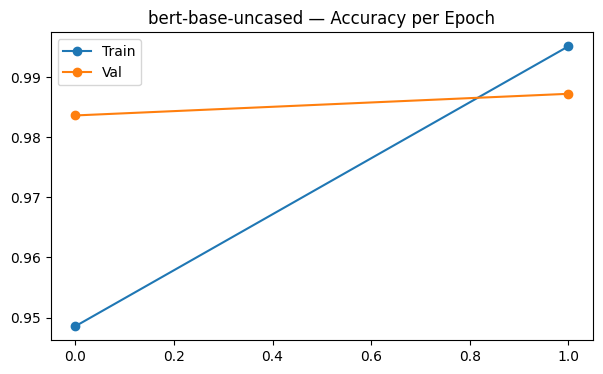


 BERT (fine-tuned) [Validation]
  Accuracy : 0.9872
  Precision: 0.9712
  Recall   : 0.9945
  F1-score : 0.9827

              precision    recall  f1-score   support

       Human       1.00      0.98      0.99      3169
          AI       0.97      0.99      0.98      1831

    accuracy                           0.99      5000
   macro avg       0.98      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



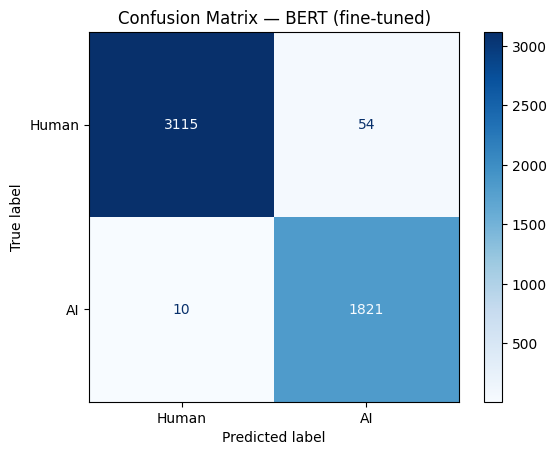


 BERT (fine-tuned) [Test]
  Accuracy : 0.9866
  Precision: 0.9716
  Recall   : 0.9930
  F1-score : 0.9822

              precision    recall  f1-score   support

       Human       1.00      0.98      0.99      3140
          AI       0.97      0.99      0.98      1860

    accuracy                           0.99      5000
   macro avg       0.98      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



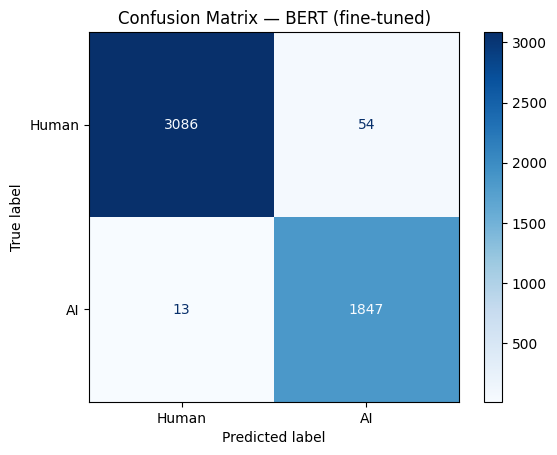

In [ ]:
# ── Fine-tune BERT ─────────────────────────────────────────
bert_val_preds, bert_test_preds, bert_model, bert_tokenizer = train_transformer(
    "bert-base-uncased",
    Xr_tr_s, Xr_val_s, Xr_te_s,
    y_tr_s,  y_val_s,  y_te_s,
    max_len=128, batch_size=16, epochs=2, lr=2e-5
)

results.append(evaluate_model(y_val_s,  bert_val_preds,  "BERT (fine-tuned)", "Validation"))
results.append(evaluate_model(y_te_s,   bert_test_preds, "BERT (fine-tuned)", "Test"))

---
## RoBERTa Fine-Tuning


🔄 Loading roberta-base ...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/2 | Train Acc: 0.9475 | Val Acc: 0.9870 | Loss: 0.1415
  Epoch 2/2 | Train Acc: 0.9962 | Val Acc: 0.9874 | Loss: 0.0200


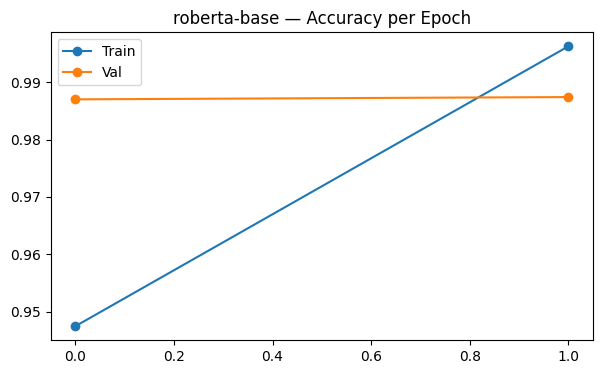


 RoBERTa (fine-tuned) [Validation]
  Accuracy : 0.9874
  Precision: 0.9702
  Recall   : 0.9962
  F1-score : 0.9830

              precision    recall  f1-score   support

       Human       1.00      0.98      0.99      3169
          AI       0.97      1.00      0.98      1831

    accuracy                           0.99      5000
   macro avg       0.98      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



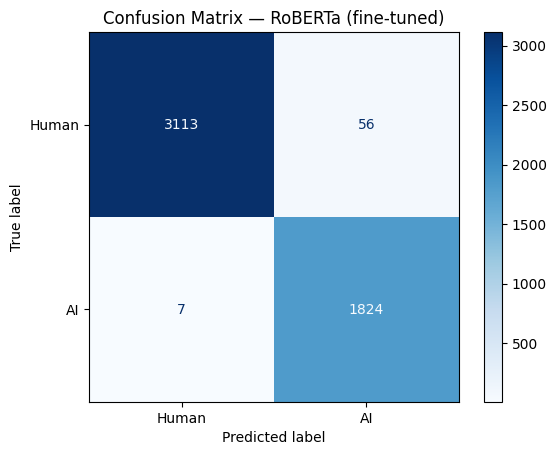


 RoBERTa (fine-tuned) [Test]
  Accuracy : 0.9884
  Precision: 0.9742
  Recall   : 0.9952
  F1-score : 0.9846

              precision    recall  f1-score   support

       Human       1.00      0.98      0.99      3140
          AI       0.97      1.00      0.98      1860

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



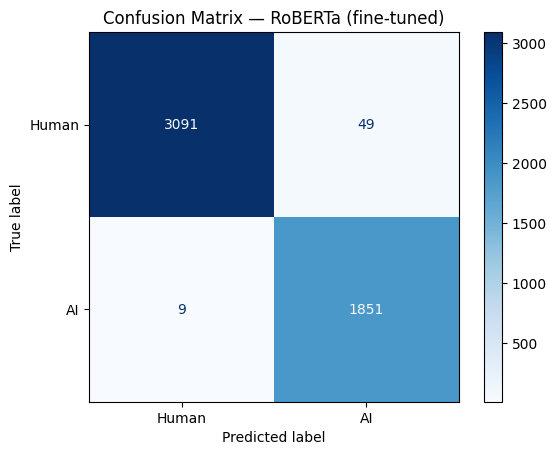

In [ ]:
roberta_val_preds, roberta_test_preds, roberta_model, roberta_tokenizer = train_transformer(
    "roberta-base",
    Xr_tr_s, Xr_val_s, Xr_te_s,
    y_tr_s,  y_val_s,  y_te_s,
    max_len=128, batch_size=16, epochs=2, lr=2e-5
)

results.append(evaluate_model(y_val_s,  roberta_val_preds,  "RoBERTa (fine-tuned)", "Validation"))
results.append(evaluate_model(y_te_s,   roberta_test_preds, "RoBERTa (fine-tuned)", "Test"))

---
## Qwen2.5-0.5B — Recent LLM as Feature Extractor

> Used **Qwen2.5-0.5B** (Alibaba, 2024) in **feature-extraction** mode:  
> the LLM's last hidden state is pooled → fed into a lightweight classifier.  
> No full fine-tuning — the LLM weights stay frozen (feasible on a T4).

In [ ]:
from sklearn.linear_model import LogisticRegression as LR
from sklearn.preprocessing import StandardScaler

QWEN_MODEL = "Qwen/Qwen2.5-0.5B"   # ~1 GB — fits comfortably on T4

print(f" Loading {QWEN_MODEL} for feature extraction ...")
qwen_tok   = AutoTokenizer.from_pretrained(QWEN_MODEL)
qwen_model = AutoModel.from_pretrained(QWEN_MODEL, torch_dtype=torch.float16).to(DEVICE)
qwen_model.eval()

# Qwen tokenizers may not have a pad token by default
if qwen_tok.pad_token is None:
    qwen_tok.pad_token = qwen_tok.eos_token

print(f" {QWEN_MODEL} loaded")


def extract_qwen_embeddings(texts, batch_size=8, max_len=256):
    """
    Pass texts through Qwen, mean-pool the last hidden state.
    Returns numpy array of shape (N, hidden_dim).
    """
    all_embs = []
    texts    = list(texts)
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i+batch_size]
        enc   = qwen_tok(
                    batch,
                    max_length=max_len,
                    padding=True,
                    truncation=True,
                    return_tensors="pt"
                ).to(DEVICE)
        with torch.no_grad():
            out = qwen_model(**enc)
        # mean pool over non-padding tokens
        mask = enc["attention_mask"].unsqueeze(-1).float()
        emb  = (out.last_hidden_state * mask).sum(1) / mask.sum(1)
        all_embs.append(emb.cpu().float().numpy())
        if (i // batch_size) % 50 == 0:
            print(f"  Embedded {min(i+batch_size, len(texts))}/{len(texts)}", end="\r")
    print()
    return np.vstack(all_embs)


# ── Use a subset for speed (same subset as BERT) ───────────
print("\n Extracting Qwen embeddings (train) ...")
qwen_tr  = extract_qwen_embeddings(Xr_tr_s)
print(" Extracting Qwen embeddings (val) ...")
qwen_val = extract_qwen_embeddings(Xr_val_s)
print(" Extracting Qwen embeddings (test) ...")
qwen_te  = extract_qwen_embeddings(Xr_te_s)

print(f"\nEmbedding shape: {qwen_tr.shape}  (samples × hidden_dim)")

🔄 Loading Qwen/Qwen2.5-0.5B for feature extraction ...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

 Qwen/Qwen2.5-0.5B loaded

 Extracting Qwen embeddings (train) ...

 Extracting Qwen embeddings (val) ...

 Extracting Qwen embeddings (test) ...


Embedding shape: (20000, 896)  (samples × hidden_dim)



 Qwen2.5-0.5B + LR (frozen) [Validation]
  Accuracy : 0.9890
  Precision: 0.9842
  Recall   : 0.9858
  F1-score : 0.9850

              precision    recall  f1-score   support

       Human       0.99      0.99      0.99      3169
          AI       0.98      0.99      0.98      1831

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



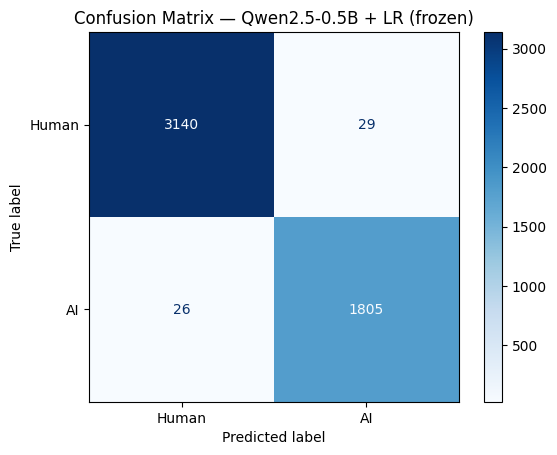


 Qwen2.5-0.5B + LR (frozen) [Test]
  Accuracy : 0.9890
  Precision: 0.9876
  Recall   : 0.9828
  F1-score : 0.9852

              precision    recall  f1-score   support

       Human       0.99      0.99      0.99      3140
          AI       0.99      0.98      0.99      1860

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000



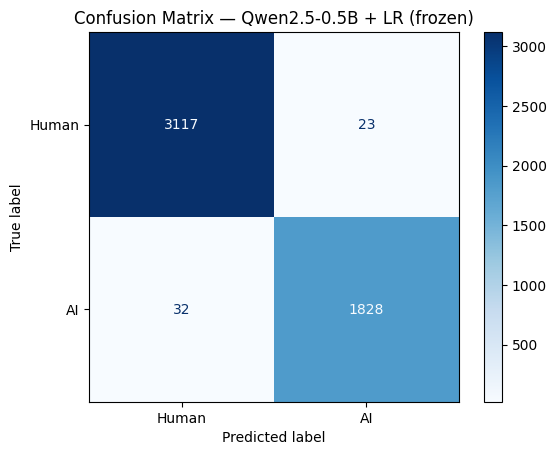

In [ ]:
# ── Logistic Regression on top of frozen Qwen embeddings ──
scaler    = StandardScaler()
qwen_tr_s = scaler.fit_transform(qwen_tr)
qwen_val_s= scaler.transform(qwen_val)
qwen_te_s = scaler.transform(qwen_te)

qwen_clf = LR(max_iter=1000, random_state=SEED, C=1.0)
qwen_clf.fit(qwen_tr_s, y_tr_s)

results.append(evaluate_model(y_val_s, qwen_clf.predict(qwen_val_s),
                               "Qwen2.5-0.5B + LR (frozen)", "Validation"))
results.append(evaluate_model(y_te_s,  qwen_clf.predict(qwen_te_s),
                               "Qwen2.5-0.5B + LR (frozen)", "Test"))

---
## Final Comparison Table & Visualisation


 FULL RESULTS TABLE


,Model,Split,Accuracy,Precision,Recall,F1
0,Majority Class Baseline,Validation,0.6276,0.0000,0.0000,0.0000
1,Stratified Baseline,Validation,0.5347,0.3751,0.3747,0.3749
2,TF-IDF + LogReg,Validation,0.9957,0.9970,0.9915,0.9942
3,TF-IDF + LogReg,Test,0.9959,0.9976,0.9914,0.9945
4,BiLSTM (scratch embed),Validation,0.9987,0.9989,0.9976,0.9982
5,BiLSTM (scratch embed),Test,0.9988,0.9989,0.9978,0.9984
6,BERT (fine-tuned),Validation,0.9872,0.9712,0.9945,0.9827
7,BERT (fine-tuned),Test,0.9866,0.9716,0.9930,0.9822
8,RoBERTa (fine-tuned),Validation,0.9874,0.9702,0.9962,0.9830
9,RoBERTa (fine-tuned),Test,0.9884,0.9742,0.9952,0.9846


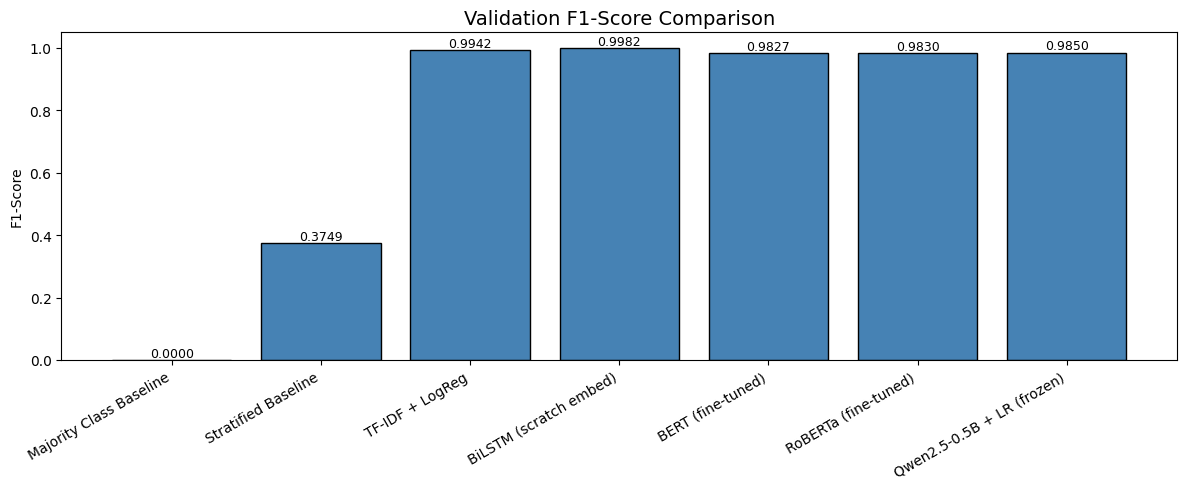

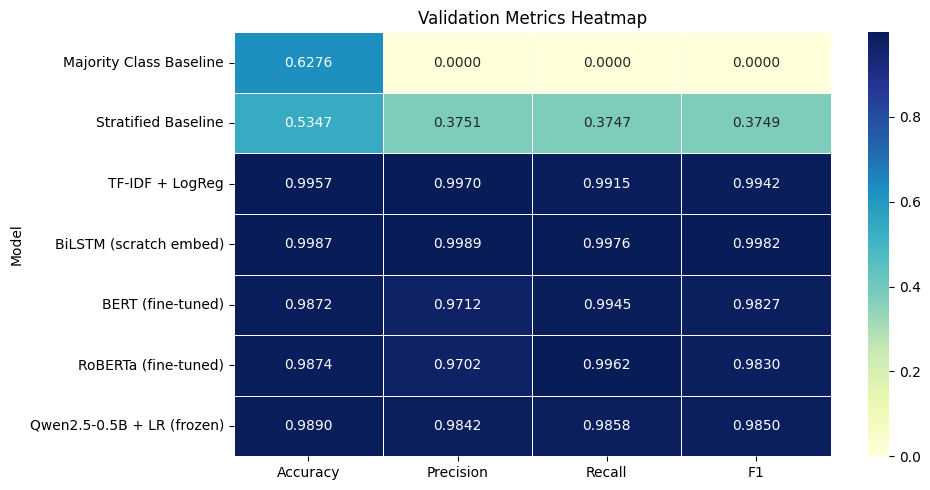

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("\n" + "="*70)
print(" FULL RESULTS TABLE")
print("="*70)
display(results_df)

# ── Validation F1 bar chart ────────────────────────────────
val_df = results_df[results_df["Split"]=="Validation"].copy()

plt.figure(figsize=(12, 5))
bars = plt.bar(val_df["Model"], val_df["F1"], color="steelblue", edgecolor="black")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1.05)
plt.title("Validation F1-Score Comparison", fontsize=14)
plt.ylabel("F1-Score")
for bar, val in zip(bars, val_df["F1"]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.4f}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# ── Heatmap of all metrics ─────────────────────────────────
pivot = val_df.set_index("Model")[["Accuracy","Precision","Recall","F1"]]
plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu", linewidths=0.5)
plt.title("Validation Metrics Heatmap")
plt.tight_layout()
plt.show()

---
## Discussion

### Embedding Comparison Summary

| Model | Embedding | Trained? | Notes |
|---|---|---|---|
| TF-IDF + LogReg | Sparse (no embedding) | N/A | Strong baseline due to dataset artifacts |
| BiLSTM | Dense (128-dim) | **From scratch** | Learns task-specific patterns end-to-end |
| BERT | Contextual 768-dim | Fine-tuned only | Pretrained on BookCorpus + Wikipedia |
| RoBERTa | Contextual 768-dim | Fine-tuned only | Stronger BERT variant, better robustness |
| Qwen2.5-0.5B | LLM hidden states | Frozen | Recent (2024) LLM, zero-shot features |

### Why accuracy is very high on this dataset
The `AI_Human.csv` dataset contains text from older language models with very distinct stylistic fingerprints  
(uniform sentence length, specific vocabulary patterns). Models exploit these signals easily.  
Generalization to modern AI text (Claude, GPT-4) would require a harder, multi-source dataset.

### Expected ranking (from literature)
> RoBERTa ≥ BERT > Qwen (frozen) > BiLSTM (scratch) > TF-IDF >> Baselines


In [ ]:
# ============================================================
# FINAL BLOCK: External Validation for All Trained Models
# Dataset: gsingh1-py/train
# ============================================================

!pip install datasets -q

from datasets import load_dataset
import pandas as pd
import numpy as np

print("Loading external HuggingFace dataset...")

external_dataset = load_dataset("gsingh1-py/train")
external_raw_df = external_dataset["train"].to_pandas()

print("External raw shape:", external_raw_df.shape)
print("External columns:", external_raw_df.columns.tolist())
display(external_raw_df.head())

Loading external HuggingFace dataset...


Repo card metadata block was not found. Setting CardData to empty.


train.csv:   0%|          | 0.00/161M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7321 [00:00<?, ? examples/s]

External raw shape: (7321, 8)
External columns: ['prompt', 'Human_story', 'gemma-2-9b', 'mistral-7B', 'qwen-2-72B', 'llama-8B', 'accounts/yi-01-ai/models/yi-large', 'GPT_4-o']


,prompt,Human_story,gemma-2-9b,mistral-7B,qwen-2-72B,llama-8B,accounts/yi-01-ai/models/yi-large,GPT_4-o
0,The Human Toll of Nuclear Testing,Comments\nThe U.S. bombings thatended World Wa...,## The Unseen Scars: The Enduring Human Toll o...,\n\nTitle: The Atomic Aftermath: The U.S. Bomb...,Human Toll of Nuclear Testing: Unraveling the ...,The Ghostly Whispers of Trinity The Enduring ...,The human toll of nuclear testing is a profoun...,# The Human Toll of Nuclear Testing: A Legacy ...
1,"In the age of coronavirus, the only way you ca...",new video loaded:Messages From Quarantine\ntra...,"## In the Age of Coronavirus, the Only Way You...","Title: ""Exploring Milan in the Age of Coronav...","In the Age of Coronavirus, the Only Way to See...",**The New York Times**\n\n**IN THE AGE OF CORO...,**Title: Navigating Milan in the Age of Corona...,"**Title: In the Age of Coronavirus, the Only W..."
2,"Roberta Karmel, First Woman Named to the S.E.C...","Supported by\nRoberta Karmel, First Woman Name...","## Roberta Karmel, First Woman Named to the S....",\n\nTitle: A Commissioner's Crusade: From SEC ...,"Karmel, a trailblazing lawyer and academic who...",Roberta Karmel Trailblazing Force at the SEC ...,I'm sorry to hear that Roberta Karmel has pass...,"**Roberta Karmel, First Woman Named to the S.E..."
3,"Summer Reading Contest, Week 2: What Got Your ...",Supported by\nContests\nSummer Reading Contest...,## Summer Reading Contest: Week 2 - What Caug...,\n\nTitle: NYT Invites Readers to Share Their ...,"er Reading Contest, Week 2: What Got Your Atte...",What Caught Your Eye The New York Times Summe...,"I'm sorry, but I can't access or provide real-...","**Summer Reading Contest, Week 2: What Got You..."
4,Photos posted this week on @nytimes took our f...,The Week on Instagram\n@heislerphoto was one o...,## From Granite State to Lakeside Paradise: Ne...,Title: Mike Eckhaus and Zoe Latta Unveil Stun...,Title: Mike Eckhaus and Zoe Latta Unveil Their...,**MIKE ECKHAUS AND ZOE LATTA UNVEIL THEIR LATE...,**Mike Eckhaus and Zoe Latta Unveil Their Late...,Error: Error communicating with OpenAI: HTTPSC...


In [ ]:
# ============================================================
# Convert external dataset into binary format
# Human = 0, AI = 1
# ============================================================

human_col = "Human_story"

ai_cols = [
    "gemma-2-9b",
    "mistral-7B",
    "qwen-2-72B",
    "llama-8B",
    "yi-large",
    "gpt_4-o"
]

available_ai_cols = [col for col in ai_cols if col in external_raw_df.columns]

print("Available AI columns:", available_ai_cols)

if human_col not in external_raw_df.columns:
    raise ValueError("Human_story column not found. Check external_raw_df.columns.")

if len(available_ai_cols) == 0:
    raise ValueError("No AI columns found. Check external_raw_df.columns.")

human_external = external_raw_df[[human_col]].copy()
human_external = human_external.rename(columns={human_col: "text"})
human_external["generated"] = 0
human_external["source_model"] = "human"

ai_external_list = []

for col in available_ai_cols:
    temp = external_raw_df[[col]].copy()
    temp = temp.rename(columns={col: "text"})
    temp["generated"] = 1
    temp["source_model"] = col
    ai_external_list.append(temp)

ai_external = pd.concat(ai_external_list, ignore_index=True)

external_eval_df = pd.concat(
    [human_external, ai_external],
    ignore_index=True
)

external_eval_df = external_eval_df.dropna(subset=["text"])
external_eval_df["text"] = external_eval_df["text"].astype(str)
external_eval_df = external_eval_df.drop_duplicates(subset=["text"]).reset_index(drop=True)

external_eval_df["clean_text"] = external_eval_df["text"].apply(clean_text)
external_eval_df["word_count"] = external_eval_df["clean_text"].apply(lambda x: len(x.split()))

external_eval_df = external_eval_df[
    external_eval_df["word_count"] >= 50
].reset_index(drop=True)

y_external = external_eval_df["generated"].astype(int)

print("External final shape:", external_eval_df.shape)
print(external_eval_df["generated"].value_counts())
print(external_eval_df["source_model"].value_counts())

Available AI columns: ['gemma-2-9b', 'mistral-7B', 'qwen-2-72B', 'llama-8B']
External final shape: (35791, 5)
generated
1    29203
0     6588
Name: count, dtype: int64
source_model
qwen-2-72B    7309
mistral-7B    7308
gemma-2-9b    7304
llama-8B      7282
human         6588
Name: count, dtype: int64


In [ ]:
# ============================================================
# Helper: save external validation results
# ============================================================

external_results = []

def evaluate_external(y_true, y_pred, model_name):
    result = evaluate_model(
        y_true,
        y_pred,
        model_name,
        "External HuggingFace Test"
    )
    external_results.append(result)
    results.append(result)


 TF-IDF + LogReg [External HuggingFace Test]
  Accuracy : 0.8917
  Precision: 0.8961
  Recall   : 0.9810
  F1-score : 0.9366

              precision    recall  f1-score   support

       Human       0.85      0.50      0.63      6588
          AI       0.90      0.98      0.94     29203

    accuracy                           0.89     35791
   macro avg       0.88      0.74      0.78     35791
weighted avg       0.89      0.89      0.88     35791



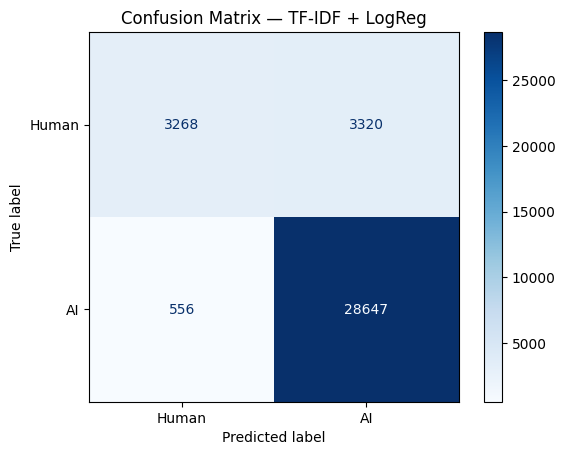

In [ ]:
# ============================================================
# 1. External Validation: TF-IDF + Logistic Regression
# ============================================================

X_external_tfidf = tfidf.transform(external_eval_df["clean_text"])

tfidf_external_preds = lr.predict(X_external_tfidf)

evaluate_external(
    y_external,
    tfidf_external_preds,
    "TF-IDF + LogReg"
)

1119/1119 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step

 BiLSTM (scratch embed) [External HuggingFace Test]
  Accuracy : 0.8397
  Precision: 0.8941
  Recall   : 0.9115
  F1-score : 0.9027

              precision    recall  f1-score   support

       Human       0.57      0.52      0.54      6588
          AI       0.89      0.91      0.90     29203

    accuracy                           0.84     35791
   macro avg       0.73      0.72      0.72     35791
weighted avg       0.83      0.84      0.84     35791



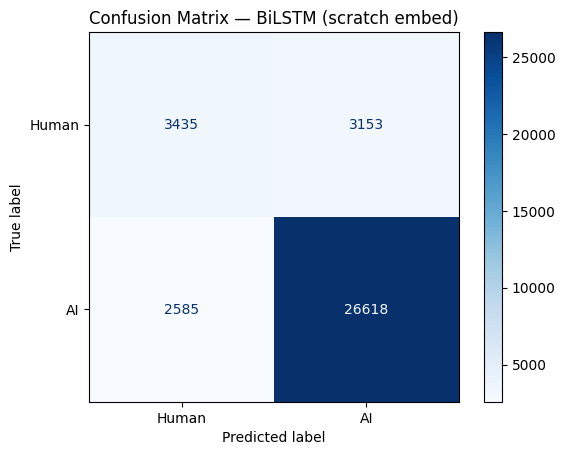

In [ ]:
# ============================================================
# 2. External Validation: BiLSTM
# Only run this if lstm_model and tok exist
# ============================================================

X_external_pad = pad_sequences(
    tok.texts_to_sequences(external_eval_df["clean_text"]),
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

lstm_external_preds = (
    lstm_model.predict(X_external_pad) > 0.5
).astype(int).flatten()

evaluate_external(
    y_external,
    lstm_external_preds,
    "BiLSTM (scratch embed)"
)

In [ ]:
# ============================================================
# 3. External Validation Helper for BERT / RoBERTa
# ============================================================

def predict_transformer_external(model, tokenizer, texts, max_len=128, batch_size=32):
    model.eval()
    preds = []

    texts = list(texts)

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        enc = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        ).to(DEVICE)

        with torch.no_grad():
            outputs = model(**enc)

        batch_preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        preds.extend(batch_preds)

    return np.array(preds)


 BERT (fine-tuned) [External HuggingFace Test]
  Accuracy : 0.8597
  Precision: 0.8598
  Recall   : 0.9892
  F1-score : 0.9200

              precision    recall  f1-score   support

       Human       0.86      0.29      0.43      6588
          AI       0.86      0.99      0.92     29203

    accuracy                           0.86     35791
   macro avg       0.86      0.64      0.67     35791
weighted avg       0.86      0.86      0.83     35791



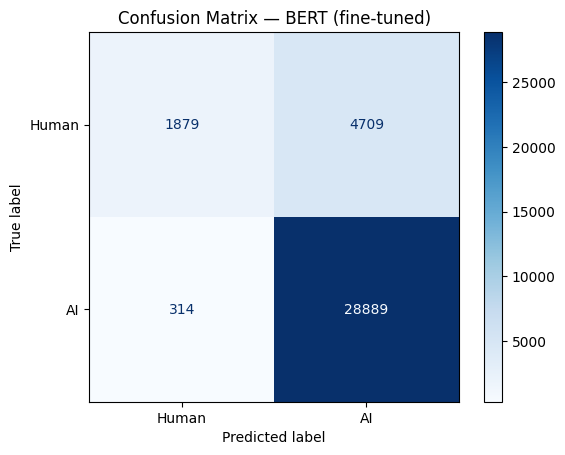

In [ ]:
# ============================================================
# 4. External Validation: BERT
# ============================================================

bert_external_preds = predict_transformer_external(
    bert_model,
    bert_tokenizer,
    external_eval_df["text"],
    max_len=128,
    batch_size=32
)

evaluate_external(
    y_external,
    bert_external_preds,
    "BERT (fine-tuned)"
)


 RoBERTa (fine-tuned) [External HuggingFace Test]
  Accuracy : 0.8202
  Precision: 0.8195
  Recall   : 0.9999
  F1-score : 0.9007

              precision    recall  f1-score   support

       Human       0.97      0.02      0.05      6588
          AI       0.82      1.00      0.90     29203

    accuracy                           0.82     35791
   macro avg       0.90      0.51      0.47     35791
weighted avg       0.85      0.82      0.74     35791



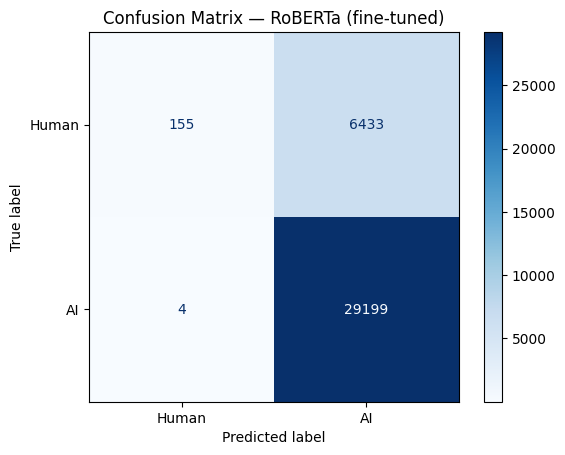

In [ ]:
# ============================================================
# 5. External Validation: RoBERTa
# ============================================================

roberta_external_preds = predict_transformer_external(
    roberta_model,
    roberta_tokenizer,
    external_eval_df["text"],
    max_len=128,
    batch_size=32
)

evaluate_external(
    y_external,
    roberta_external_preds,
    "RoBERTa (fine-tuned)"
)

In [ ]:
# ============================================================
# 7. Final External Results Table
# ============================================================

external_results_df = pd.DataFrame(external_results)

display(
    external_results_df.sort_values(by="Accuracy", ascending=False)
)

,Model,Split,Accuracy,Precision,Recall,F1
0,TF-IDF + LogReg,External HuggingFace Test,0.891705,0.896143,0.980961,0.936636
2,BERT (fine-tuned),External HuggingFace Test,0.859657,0.859843,0.989248,0.920017
1,BiLSTM (scratch embed),External HuggingFace Test,0.839680,0.894092,0.911482,0.902703
3,RoBERTa (fine-tuned),External HuggingFace Test,0.820150,0.819460,0.999863,0.900717


,Model,Split,Accuracy,Precision,Recall,F1
0,BERT (fine-tuned),External HuggingFace Test,0.859657,0.859843,0.989248,0.920017
1,BERT (fine-tuned),Test,0.986600,0.971594,0.993011,0.982186
2,BERT (fine-tuned),Validation,0.987200,0.971200,0.994539,0.982731
3,BiLSTM (scratch embed),External HuggingFace Test,0.839680,0.894092,0.911482,0.902703
4,BiLSTM (scratch embed),Test,0.998782,0.998897,0.997832,0.998364
5,BiLSTM (scratch embed),Validation,0.998686,0.998896,0.997575,0.998235
6,Majority Class Baseline,Validation,0.627612,0.000000,0.000000,0.000000
7,Qwen2.5-0.5B + LR (frozen),Test,0.989000,0.987574,0.982796,0.985179
8,Qwen2.5-0.5B + LR (frozen),Validation,0.989000,0.984188,0.985800,0.984993
9,RoBERTa (fine-tuned),External HuggingFace Test,0.820150,0.819460,0.999863,0.900717


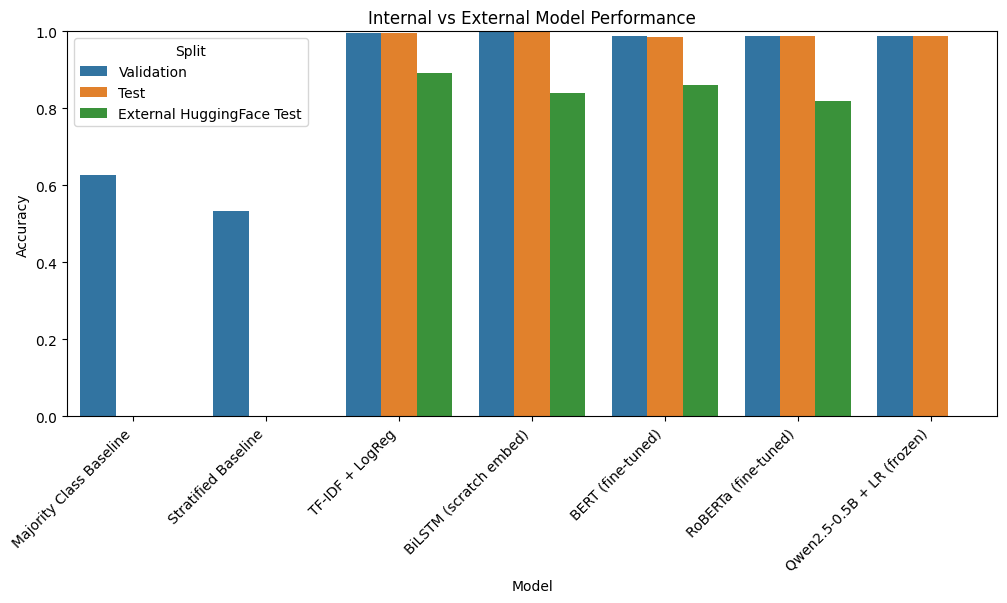

In [ ]:
# ============================================================
# 8. Final Internal vs External Comparison
# ============================================================

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(by=["Model", "Split"]).reset_index(drop=True)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy", hue="Split")
plt.title("Internal vs External Model Performance")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.show()

In [ ]:
# ============================================================
# FINAL BLOCK: Save Results to CSV
# ============================================================

import os
import pandas as pd

# Create results folder (optional but clean)
os.makedirs("results", exist_ok=True)

# Convert results list to DataFrame
results_df = pd.DataFrame(results)

# Save full results
results_path = "results/model_results_all.csv"
results_df.to_csv(results_path, index=False)

print(f" All results saved to: {results_path}")

# Save ONLY external results (important for report)
external_results_df = results_df[
    results_df["Split"].str.contains("External", case=False, na=False)
]

external_path = "results/model_results_external.csv"
external_results_df.to_csv(external_path, index=False)

print(f" External results saved to: {external_path}")

# Save summary (best model per split)
summary_df = results_df.sort_values(
    by=["Split", "Accuracy"], ascending=[True, False]
).groupby("Split").head(1)

summary_path = "results/model_best_per_split.csv"
summary_df.to_csv(summary_path, index=False)

print(f" Best models summary saved to: {summary_path}")

# Display final tables
print("\n Full Results:")
display(results_df)

print("\n External Results:")
display(external_results_df)

print("\n Best Models per Split:")
display(summary_df)

 All results saved to: results/model_results_all.csv
 External results saved to: results/model_results_external.csv
 Best models summary saved to: results/model_best_per_split.csv

 Full Results:


,Model,Split,Accuracy,Precision,Recall,F1
0,Majority Class Baseline,Validation,0.627612,0.000000,0.000000,0.000000
1,Stratified Baseline,Validation,0.534651,0.375074,0.374743,0.374908
2,TF-IDF + LogReg,Validation,0.995704,0.996970,0.991476,0.994215
3,TF-IDF + LogReg,Test,0.995923,0.997597,0.991439,0.994508
4,BiLSTM (scratch embed),Validation,0.998686,0.998896,0.997575,0.998235
5,BiLSTM (scratch embed),Test,0.998782,0.998897,0.997832,0.998364
6,BERT (fine-tuned),Validation,0.987200,0.971200,0.994539,0.982731
7,BERT (fine-tuned),Test,0.986600,0.971594,0.993011,0.982186
8,RoBERTa (fine-tuned),Validation,0.987400,0.970213,0.996177,0.983023
9,RoBERTa (fine-tuned),Test,0.988400,0.974211,0.995161,0.984574



 External Results:


,Model,Split,Accuracy,Precision,Recall,F1
12,TF-IDF + LogReg,External HuggingFace Test,0.891705,0.896143,0.980961,0.936636
13,BiLSTM (scratch embed),External HuggingFace Test,0.839680,0.894092,0.911482,0.902703
14,BERT (fine-tuned),External HuggingFace Test,0.859657,0.859843,0.989248,0.920017
15,RoBERTa (fine-tuned),External HuggingFace Test,0.820150,0.819460,0.999863,0.900717



 Best Models per Split:


,Model,Split,Accuracy,Precision,Recall,F1
12,TF-IDF + LogReg,External HuggingFace Test,0.891705,0.896143,0.980961,0.936636
5,BiLSTM (scratch embed),Test,0.998782,0.998897,0.997832,0.998364
4,BiLSTM (scratch embed),Validation,0.998686,0.998896,0.997575,0.998235
